<a href="https://colab.research.google.com/github/kallydimitrova/HEPexercises/blob/main/Exercise5_LIGO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import h5py

def load_gwosc_strain(path):
    with h5py.File(path, "r") as f:
        strain = f["strain"]["Strain"][:]
        dt = f["strain"]["Strain"].attrs["Xspacing"]
        t0_gps = f["meta"]["GPSstart"][()]
        detector = f["meta"]["Detector"][()]
        if isinstance(detector, bytes):
            detector = detector.decode()
    return strain, dt, t0_gps, detector

strain_h1, dt, t0_gps, det = load_gwosc_strain(
    "data/H-H1_GWOSC_4KHZ_R1-1126259447-32.hdf5")

fs = 1.0 / dt
N = len(strain_h1)
duration = N * dt
f_nyquist = fs / 2

print(f"Detector: {det}")
print(f"Sampling frequency: fs = {fs:.0f} Hz  (Nyquist = {f_nyquist:.0f} Hz)")
print(f"Number of samples: N = {N}")
print(f"Duration: N * dt = {duration:.3f} s")

t = np.arange(N) * dt  # seconds from the start of the file
GW150914_GPS = 1126259462.4
t_merger_in_file = GW150914_GPS - t0_gps
print(f"Merger occurs at t = {t_merger_in_file:.2f} s into the file")

Detector: H1
Sampling frequency: fs = 4096 Hz  (Nyquist = 2048 Hz)
Number of samples: N = 131072
Duration: N * dt = 32.000 s
Merger occurs at t = 15.40 s into the file


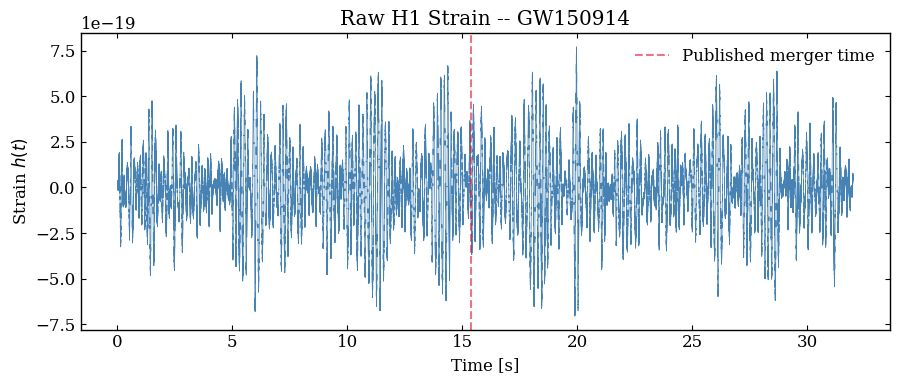

In [16]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12, "font.family": "serif", "axes.linewidth": 1.0,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "legend.frameon": False, "savefig.bbox": "tight",
})

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, strain_h1, color="steelblue", linewidth=0.5)
ax.axvline(t_merger_in_file, color="crimson", linestyle="--",
           alpha=0.6, label="Published merger time")
ax.set_xlabel("Time [s]"); ax.set_ylabel("Strain $h(t)$")
ax.set_title("Raw H1 Strain -- GW150914")
ax.legend(); fig.tight_layout()
fig.savefig("figures/raw_strain.png", dpi=300)

In [17]:
from scipy.signal import butter, filtfilt

def bandpass_filter(data, fs, f_low=35.0, f_high=350.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [f_low / nyq, f_high / nyq], btype="band")
    return filtfilt(b, a, data)  # zero-phase filtering

strain_filtered = bandpass_filter(strain_h1, fs)
print(f"Filtered {len(strain_filtered)} samples between 35 and 350 Hz "
      f"(order-4 Butterworth, zero-phase).")

Filtered 131072 samples between 35 and 350 Hz (order-4 Butterworth, zero-phase).


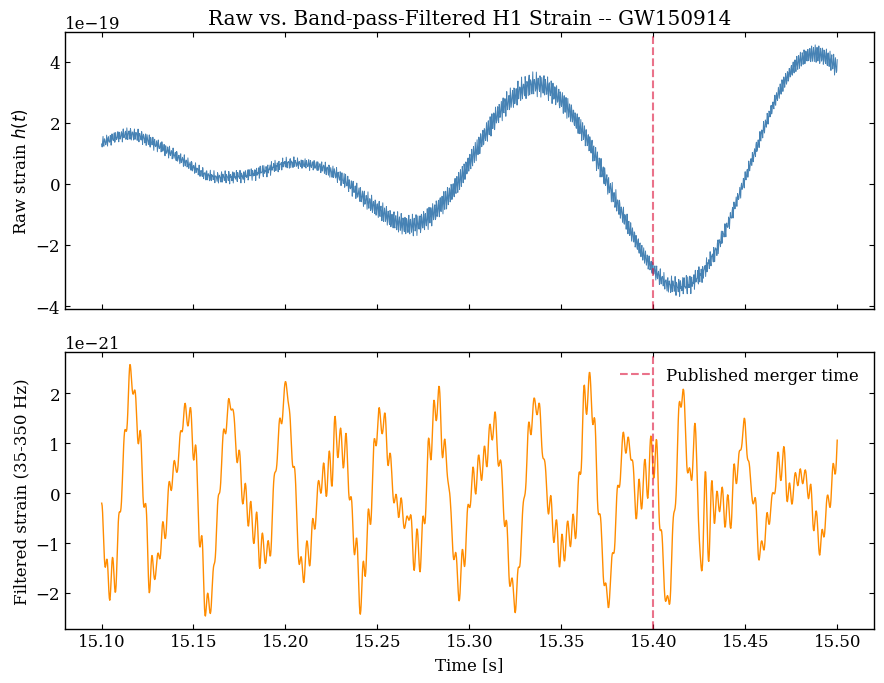

In [18]:
zoom = (t > t_merger_in_file - 0.3) & (t < t_merger_in_file + 0.1)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axes[0].plot(t[zoom], strain_h1[zoom], color="steelblue", linewidth=0.7)
axes[0].axvline(t_merger_in_file, color="crimson", linestyle="--", alpha=0.6)
axes[0].set_ylabel("Raw strain $h(t)$")
axes[0].set_title("Raw vs. Band-pass-Filtered H1 Strain -- GW150914")

axes[1].plot(t[zoom], strain_filtered[zoom], color="darkorange", linewidth=1.0)
axes[1].axvline(t_merger_in_file, color="crimson", linestyle="--", alpha=0.6,
                 label="Published merger time")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Filtered strain (35-350 Hz)")
axes[1].legend()

fig.tight_layout()
fig.savefig("figures/filtered_strain_chirp.png", dpi=300)

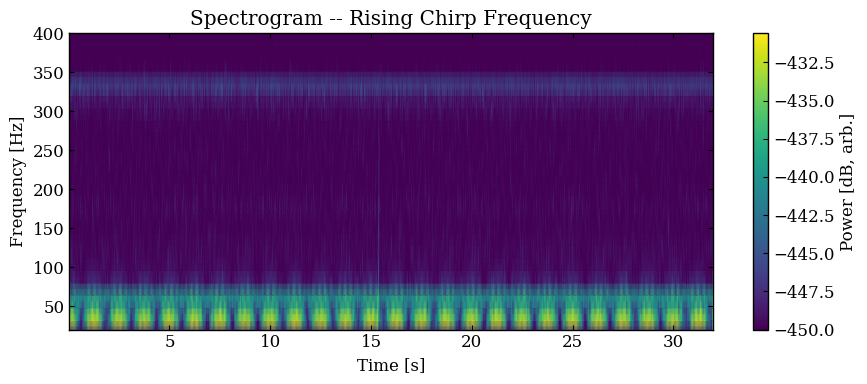

In [19]:
from scipy.signal import spectrogram

f_spec, t_spec, Sxx = spectrogram(strain_filtered, fs=fs,
                                   nperseg=256, noverlap=224)

fig, ax = plt.subplots(figsize=(9, 4))
pcm = ax.pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx + 1e-45),
                     shading="gouraud", cmap="viridis")
ax.set_ylim(20, 400)
ax.set_xlabel("Time [s]"); ax.set_ylabel("Frequency [Hz]")
ax.set_title("Spectrogram -- Rising Chirp Frequency")
fig.colorbar(pcm, ax=ax, label="Power [dB, arb.]")
fig.tight_layout()
fig.savefig("figures/spectrogram.png", dpi=300)

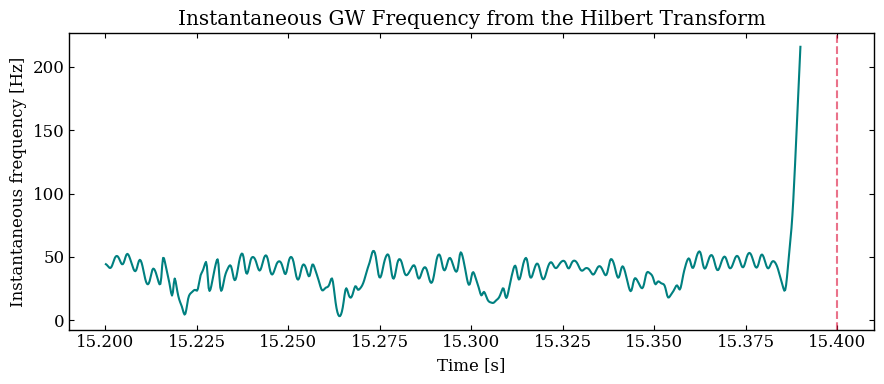

In [20]:
from scipy.signal import hilbert, savgol_filter

def instantaneous_frequency(signal, fs, smooth_window=51, smooth_order=3):
    analytic = hilbert(signal)
    phase = np.unwrap(np.angle(analytic))
    freq = np.gradient(phase) * fs / (2 * np.pi)

    if smooth_window > 1:
        freq = savgol_filter(freq, smooth_window, smooth_order)
    return freq

freq = instantaneous_frequency(strain_filtered, fs)

zoom_freq = (t > t_merger_in_file - 0.2) & (t < t_merger_in_file - 0.01)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t[zoom_freq], freq[zoom_freq], color="teal")
ax.axvline(t_merger_in_file, color="crimson", linestyle="--", alpha=0.6)
ax.set_xlabel("Time [s]"); ax.set_ylabel("Instantaneous frequency [Hz]")
ax.set_title("Instantaneous GW Frequency from the Hilbert Transform")
fig.tight_layout()
fig.savefig("figures/instantaneous_frequency.png", dpi=300)

In [22]:
dfdt = np.gradient(freq) * fs

window = (t > t_merger_in_file - 0.15) & (t < t_merger_in_file - 0.02) \
         & (freq > 35) & (freq < 300)

print(f"Using {window.sum()} samples in the fit window")
print(f"Frequency range in window: [{freq[window].min():.1f}, "
      f"{freq[window].max():.1f}] Hz")
print(f"Median df/dt in window: {np.median(dfdt[window]):.1f} Hz/s")

Using 343 samples in the fit window
Frequency range in window: [35.1, 54.7] Hz
Median df/dt in window: 356.0 Hz/s


In [24]:
G = 6.674e-11        # m^3 kg^-1 s^-2
C_LIGHT = 2.998e8    # m/s
M_SUN = 1.989e30     # kg

def chirp_mass_from_freq(freq, dfdt):
    with np.errstate(invalid="ignore"):
        M_kg = (C_LIGHT**3 / G) * (5.0/96.0 * np.pi**(-8/3)
                                    * freq**(-11/3) * dfdt)**(3/5)
    return M_kg / M_SUN

M_est_array = chirp_mass_from_freq(freq[window], dfdt[window])
M_est_array = M_est_array[np.isfinite(M_est_array)
                           & (M_est_array > 0) & (M_est_array < 200)]

M_mean = M_est_array.mean()
M_std = M_est_array.std()
print(f"Estimated chirp mass: M = {M_mean:.1f} +/- {M_std:.1f} M_sun "
      f"(from {len(M_est_array)} samples in the fit window)")
print(f"Published GWTC-1 value: M = 28.6 (+1.7/-1.5) M_sun")
print(f"Fractional difference from GWTC-1: "
      f"{100*(M_mean - 28.6)/28.6:.0f}%")

Estimated chirp mass: M = 123.2 +/- 46.1 M_sun (from 56 samples in the fit window)
Published GWTC-1 value: M = 28.6 (+1.7/-1.5) M_sun
Fractional difference from GWTC-1: 331%


Correlation peak at t = 15.47 s (published merger: t = 15.40 s)


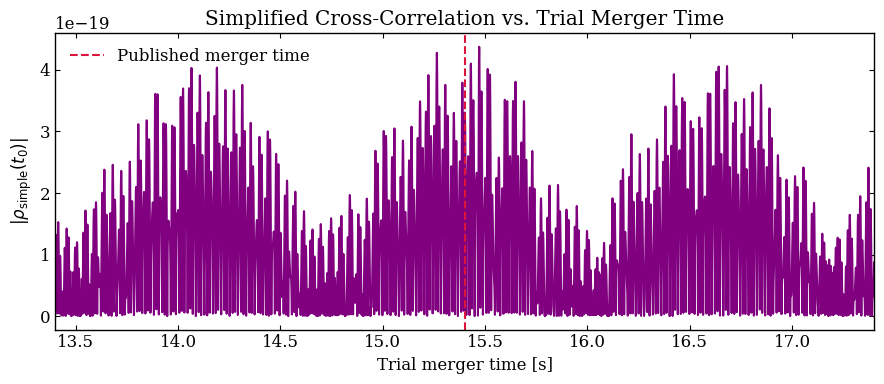

In [25]:
from scipy.signal import correlate

def simple_chirp_template(t_rel, t_c, f_start=35.0, fs=4096.0):
    tau = np.clip(t_c - t_rel, 1e-4, None)
    f_t = f_start * (tau / tau.max())**(-3/8)
    f_t = np.clip(f_t, 0, fs / 2 * 0.9)  # avoid aliasing near Nyquist

    phase = 2 * np.pi * np.cumsum(f_t) / fs
    template = np.sin(phase)

    window_taper = np.ones_like(template)
    n_taper = len(template) // 10
    taper = 0.5 * (1 - np.cos(np.linspace(0, np.pi, n_taper)))
    window_taper[:n_taper] *= taper
    window_taper[-n_taper:] *= taper[::-1]
    return template * window_taper

template_duration = 0.4  # s
n_template = int(template_duration * fs)
t_template = np.arange(n_template) / fs
template = simple_chirp_template(t_template, t_c=template_duration, fs=fs)

correlation = correlate(strain_filtered, template, mode="valid")
peak_idx = np.argmax(np.abs(correlation))
t_peak = t[peak_idx] + template_duration  # account for template length
print(f"Correlation peak at t = {t_peak:.2f} s "
      f"(published merger: t = {t_merger_in_file:.2f} s)")

fig, ax = plt.subplots(figsize=(9, 4))
t_corr = t[:len(correlation)] + template_duration
ax.plot(t_corr, np.abs(correlation), color="purple")
ax.axvline(t_merger_in_file, color="crimson", linestyle="--",
           label="Published merger time")
ax.set_xlim(t_merger_in_file - 2, t_merger_in_file + 2)
ax.set_xlabel("Trial merger time [s]"); ax.set_ylabel(r"$|\rho_{\rm simple}(t_0)|$")
ax.set_title("Simplified Cross-Correlation vs. Trial Merger Time")
ax.legend(); fig.tight_layout()
fig.savefig("figures/matched_filter_correlation.png", dpi=300)